In [6]:
!pip install movingpandas geopandas hvplot holoviews mapclassify --quiet

In [7]:
!pip install fiona

In [8]:
%matplotlib inline

import urllib
import os
import numpy as np
import pandas as pd
from geopandas import GeoDataFrame, read_file
from shapely.geometry import Point, LineString, Polygon
from fiona.crs import from_epsg
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

import sys
sys.path.append("..")
import movingpandas as mpd
import geopandas as gpd



import hvplot.pandas
from holoviews import opts
opts.defaults(opts.Overlay(active_tools=['wheel_zoom']))



import xarray as xr
from scipy.interpolate import LSQUnivariateSpline, UnivariateSpline

import warnings
warnings.simplefilter("ignore")
CRS_METRIC = from_epsg(4326)

In [9]:
from google.colab import drive

print("Mounting Google Drive...")
drive.mount('/content/drive')


Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
file_path = "/content/drive/MyDrive/LCO2 Transport Project Final/AIS_2025_Tanker.csv"

df = pd.read_csv(file_path)
len(df)

4286591

In [11]:
df.head()

,MMSI,BaseDateTime,LON,LAT,SOG,COG,Heading,IMO,Status,Length,Width,Draft,Cargo
0,563126300,2025-01-01 00:00:03,-93.95424,29.83225,7.5,11.5,8.0,IMO9864318,0.0,230.0,37.0,8.2,80.0
1,257501000,2025-01-01 00:00:03,-94.65217,29.00536,14.0,48.5,44.0,IMO9818539,0.0,183.0,32.0,8.8,82.0
2,413770000,2025-01-01 00:00:02,-125.92464,48.24089,2.0,288.0,227.0,IMO9397755,0.0,245.0,42.0,10.1,80.0
3,352003378,2025-01-01 00:00:00,-114.89276,23.26644,15.2,297.1,297.0,IMO9379399,0.0,227.0,32.0,12.2,89.0
4,255806058,2025-01-01 00:00:01,-123.12233,37.02871,11.9,355.8,352.0,IMO9783007,0.0,237.0,44.0,12.7,80.0


In [12]:
df.describe()

,MMSI,LON,LAT,SOG,COG,Heading,Status,Length,Width,Draft,Cargo
count,4.286591e+06,4.286591e+06,4.286591e+06,4.286591e+06,4.274743e+06,4.261238e+06,4.286030e+06,4.286591e+06,4.286591e+06,4.286591e+06,4.286591e+06
mean,4.384336e+08,-9.491279e+01,3.094347e+01,4.368746e+00,1.881861e+02,1.742887e+02,1.726404e+00,2.064043e+02,3.442776e+01,9.303050e+00,8.140290e+01
std,1.435647e+08,1.600392e+01,6.407035e+00,5.912450e+00,1.010590e+02,1.002769e+02,2.121585e+00,5.280248e+01,9.545709e+00,2.460380e+00,3.002416e+00
min,2.050970e+08,-1.733146e+02,1.086790e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.400000e+01,4.000000e+00,7.000000e-01,8.000000e+01
25%,3.110153e+08,-9.626824e+01,2.783503e+01,0.000000e+00,1.091000e+02,9.200000e+01,0.000000e+00,1.820000e+02,2.800000e+01,7.900000e+00,8.000000e+01
50%,4.401220e+08,-9.441395e+01,2.939496e+01,1.000000e-01,1.853000e+02,1.670000e+02,1.000000e+00,1.830000e+02,3.200000e+01,8.800000e+00,8.000000e+01
75%,5.630453e+08,-8.608875e+01,3.286103e+01,1.100000e+01,2.756000e+02,2.630000e+02,5.000000e+00,2.440000e+02,4.300000e+01,1.080000e+01,8.000000e+01
max,7.750940e+08,-6.000097e+01,5.720770e+01,4.000000e+01,3.599000e+02,3.590000e+02,1.300000e+01,3.400000e+02,6.000000e+01,2.250000e+01,8.900000e+01


In [13]:
df.isnull().sum()

,0
MMSI,0
BaseDateTime,0
LON,0
LAT,0
SOG,0
COG,11848
Heading,25353
IMO,8554
Status,561
Length,0


In [14]:
df_copy=df.copy()
len(df_copy)

4286591

In [15]:
df_copy.columns

Index(['MMSI', 'BaseDateTime', 'LON', 'LAT', 'SOG', 'COG', 'Heading', 'IMO',
       'Status', 'Length', 'Width', 'Draft', 'Cargo'],
      dtype='object')


The dataset contains **13 columns** .

**A. Identifiers**
* **`MMSI`**: *Maritime Mobile Service Identity.* A unique 9-digit radio ID. We use this to track individual vessels over time.
* **`IMO`**: *International Maritime Organization Number.* A permanent 7-digit ID that stays with the hull regardless of owner/flag changes.
* **`VesselName`**: The ship's name (e.g., "KRISTEN SPIRIT"). Often contains typos; used for validation only.
* **`CallSign`**: Radio call sign (e.g., "WDF456"). Used for voice comms; largely irrelevant for traffic modeling.

**B. Navigation & Dynamics**
* **`BaseDateTime`**: The UTC timestamp of the signal. This is the primary time axis for our time-series analysis.
* **`LAT` / `LON`**: *Latitude/Longitude.* The ship's GPS position. Used to map traffic corridors and calculate congestion density.
* **`SOG`**: *Speed Over Ground.* The actual GPS speed (knots). **Target Variable:** This is what our model will try to predict.
* **`COG`**: *Course Over Ground.* The direction of movement (0-360°).
* **`Heading`**: The direction the ship's nose is pointing. Difference between COG and Heading indicates drift (weather impact).
* **`Status`**: Navigational status (0=Underway, 1=Anchored, 5=Moored). We filter for **Status 0** to model active traffic.

**C. Vessel Specifications**
* **`Cargo`**: Numeric code for ship class. We filter for **Tankers (80–89)** relevant to CCS transport.
* **`Length` / `Width`**: Ship dimensions in meters. Critical for calculating the "traffic footprint" (space occupied per ship).
* **`Draft`**: Depth of the ship below waterline. Indicates load status (High draft = Full cargo; Low draft = Ballast/Empty).

In [16]:
df_copy['MMSI'].value_counts()

,count
MMSI,
352003638,8754
367635000,8754
244283000,8730
311000111,8724
311000112,8704
...,...
620999854,1
255806343,1
316022391,1


In [17]:
print(df_copy['MMSI'].value_counts().to_string())

MMSI
352003638    8754
367635000    8754
244283000    8730
311000111    8724
311000112    8704
367353660    8661
352004278    8649
538005550    8606
352004315    8594
369042000    8528
367597640    8508
303104000    8482
338221000    8418
368589000    8230
367353090    8212
338879000    8185
367036000    8183
367677560    8144
367102000    8025
316013215    7948
369043000    7928
367740790    7830
367481310    7786
338110000    7776
368199000    7696
338302000    7685
235076282    7663
367342960    7621
369225000    7544
229957000    7540
538004199    7502
636017991    7499
566690000    7494
538004638    7456
338188000    7416
338617000    7313
367455770    7275
369142000    7198
367381000    7184
368004000    7181
368295000    7169
366962000    7153
316013209    7152
235076283    7134
366495000    7105
367865000    6915
316055401    6862
369526000    6862
367362010    6861
367633000    6834
636015336    6808
352004308    6788
303520000    6770
367353070    6748
563326000    6745
36770

Few ships are having only 1 row of data. These are of no use to us. Let's inspect this

In [18]:
mmsi_counts = df_copy['MMSI'].value_counts()
mmsis = mmsi_counts[mmsi_counts == 1].index

check = df_copy[df_copy['MMSI'].isin(mmsis)][['MMSI', 'IMO', 'Length', 'Draft', 'SOG']]

# Show the first 20
check.head(20)

,MMSI,IMO,Length,Draft,SOG
595398,374104000,IMO9182306,333.0,11.2,6.1
672201,636016903,IMO9172583,274.0,9.4,6.6
1072030,368115380,NaN,47.0,6.7,0.0
2309103,255806343,IMO9892494,150.0,11.8,10.1
2442653,316022391,IMO9601027,225.0,8.0,11.4
3592080,620999854,IMO9281011,250.0,9.3,0.0
3592088,677038300,IMO9590008,332.0,12.5,0.0


Dropping all rows where ship is having <=50 rows of data

In [19]:
mmsi_counts = df_copy['MMSI'].value_counts()
mmsis_to_remove = mmsi_counts[mmsi_counts <= 50].index

under_50 = df_copy[df_copy['MMSI'].isin(mmsis_to_remove)][['MMSI', 'IMO', 'Length', 'Width', 'Draft', 'SOG']].drop_duplicates(subset=['MMSI'])

# Showing the results
from google.colab import data_table
data_table.enable_dataframe_formatter()

print(f"Total unique ships with <= 50 pings: {len(under_50)}")
under_50

Total unique ships with <= 50 pings: 144


,MMSI,IMO,Length,Width,Draft,SOG
143,636021552,IMO9422639,184.0,27.0,8.8,0.0
151,352001342,IMO9911525,186.0,32.0,8.0,12.5
165,477706500,IMO9762986,336.0,60.0,20.3,12.9
177,219027877,IMO9290579,183.0,32.0,8.0,12.3
359,538004885,IMO9416109,144.0,24.0,9.9,0.0
...,...,...,...,...,...,...
4243623,228458900,IMO9709075,333.0,60.0,11.0,15.3
4252145,477539800,IMO9831854,275.0,48.0,16.8,0.6
4269774,241493000,IMO9645437,274.0,48.0,9.0,8.7
4271639,563205600,IMO9409479,228.0,32.0,12.7,8.0


In [20]:
len(under_50)

144

In [21]:
df_clean = df_copy[df_copy['Heading'] <= 360].copy()
mmsi_counts = df_clean['MMSI'].value_counts()
df_final = df_clean[df_clean['MMSI'].isin(mmsi_counts[mmsi_counts > 50].index)]
removed_rows = len(df_copy) - len(df_final)
print(f" Removed {removed_rows} rows of noise.")
print(f"Remaining Data: {len(df_final)} rows.")
print(f"Total Unique Ships for Analysis: {df_final['MMSI'].nunique()}")

 Removed 28161 rows of noise.
Remaining Data: 4258430 rows.
Total Unique Ships for Analysis: 3612


In [22]:
count_outliers = (df_copy['Heading'] > 360).sum()
print(f"Number of broken sensors: {count_outliers}")

Number of broken sensors: 0


In [23]:
df_final['MMSI'].value_counts()

,count
MMSI,
352003638,8754
367635000,8754
244283000,8729
311000111,8724
311000112,8704
...,...
538010892,52
636025316,52
374075000,51


NEARLY 3600 SHIPS


In [24]:
df_final.describe()

,MMSI,LON,LAT,SOG,COG,Heading,Status,Length,Width,Draft,Cargo
count,4.258430e+06,4.258430e+06,4.258430e+06,4.258430e+06,4.254495e+06,4.258430e+06,4.257872e+06,4.258430e+06,4.258430e+06,4.258430e+06,4.258430e+06
mean,4.388127e+08,-9.486144e+01,3.093578e+01,4.386383e+00,1.883517e+02,1.742909e+02,1.724155e+00,2.065914e+02,3.447065e+01,9.315422e+00,8.139500e+01
std,1.437619e+08,1.596134e+01,6.394799e+00,5.919091e+00,1.009362e+02,1.002776e+02,2.121055e+00,5.267756e+01,9.522917e+00,2.450363e+00,2.993621e+00
min,2.050970e+08,-1.733146e+02,1.086790e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.400000e+01,4.000000e+00,7.000000e-01,8.000000e+01
25%,3.110016e+08,-9.621647e+01,2.783461e+01,0.000000e+00,1.093000e+02,9.200000e+01,0.000000e+00,1.820000e+02,2.800000e+01,7.900000e+00,8.000000e+01
50%,4.770101e+08,-9.441267e+01,2.938728e+01,1.000000e-01,1.854000e+02,1.670000e+02,1.000000e+00,1.830000e+02,3.200000e+01,8.800000e+00,8.000000e+01
75%,5.630475e+08,-8.605855e+01,3.286102e+01,1.100000e+01,2.756000e+02,2.630000e+02,5.000000e+00,2.440000e+02,4.300000e+01,1.080000e+01,8.000000e+01
max,7.100333e+08,-6.000097e+01,5.720770e+01,4.000000e+01,3.599000e+02,3.590000e+02,1.300000e+01,3.400000e+02,6.000000e+01,2.250000e+01,8.900000e+01


# VISUALISATION


In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

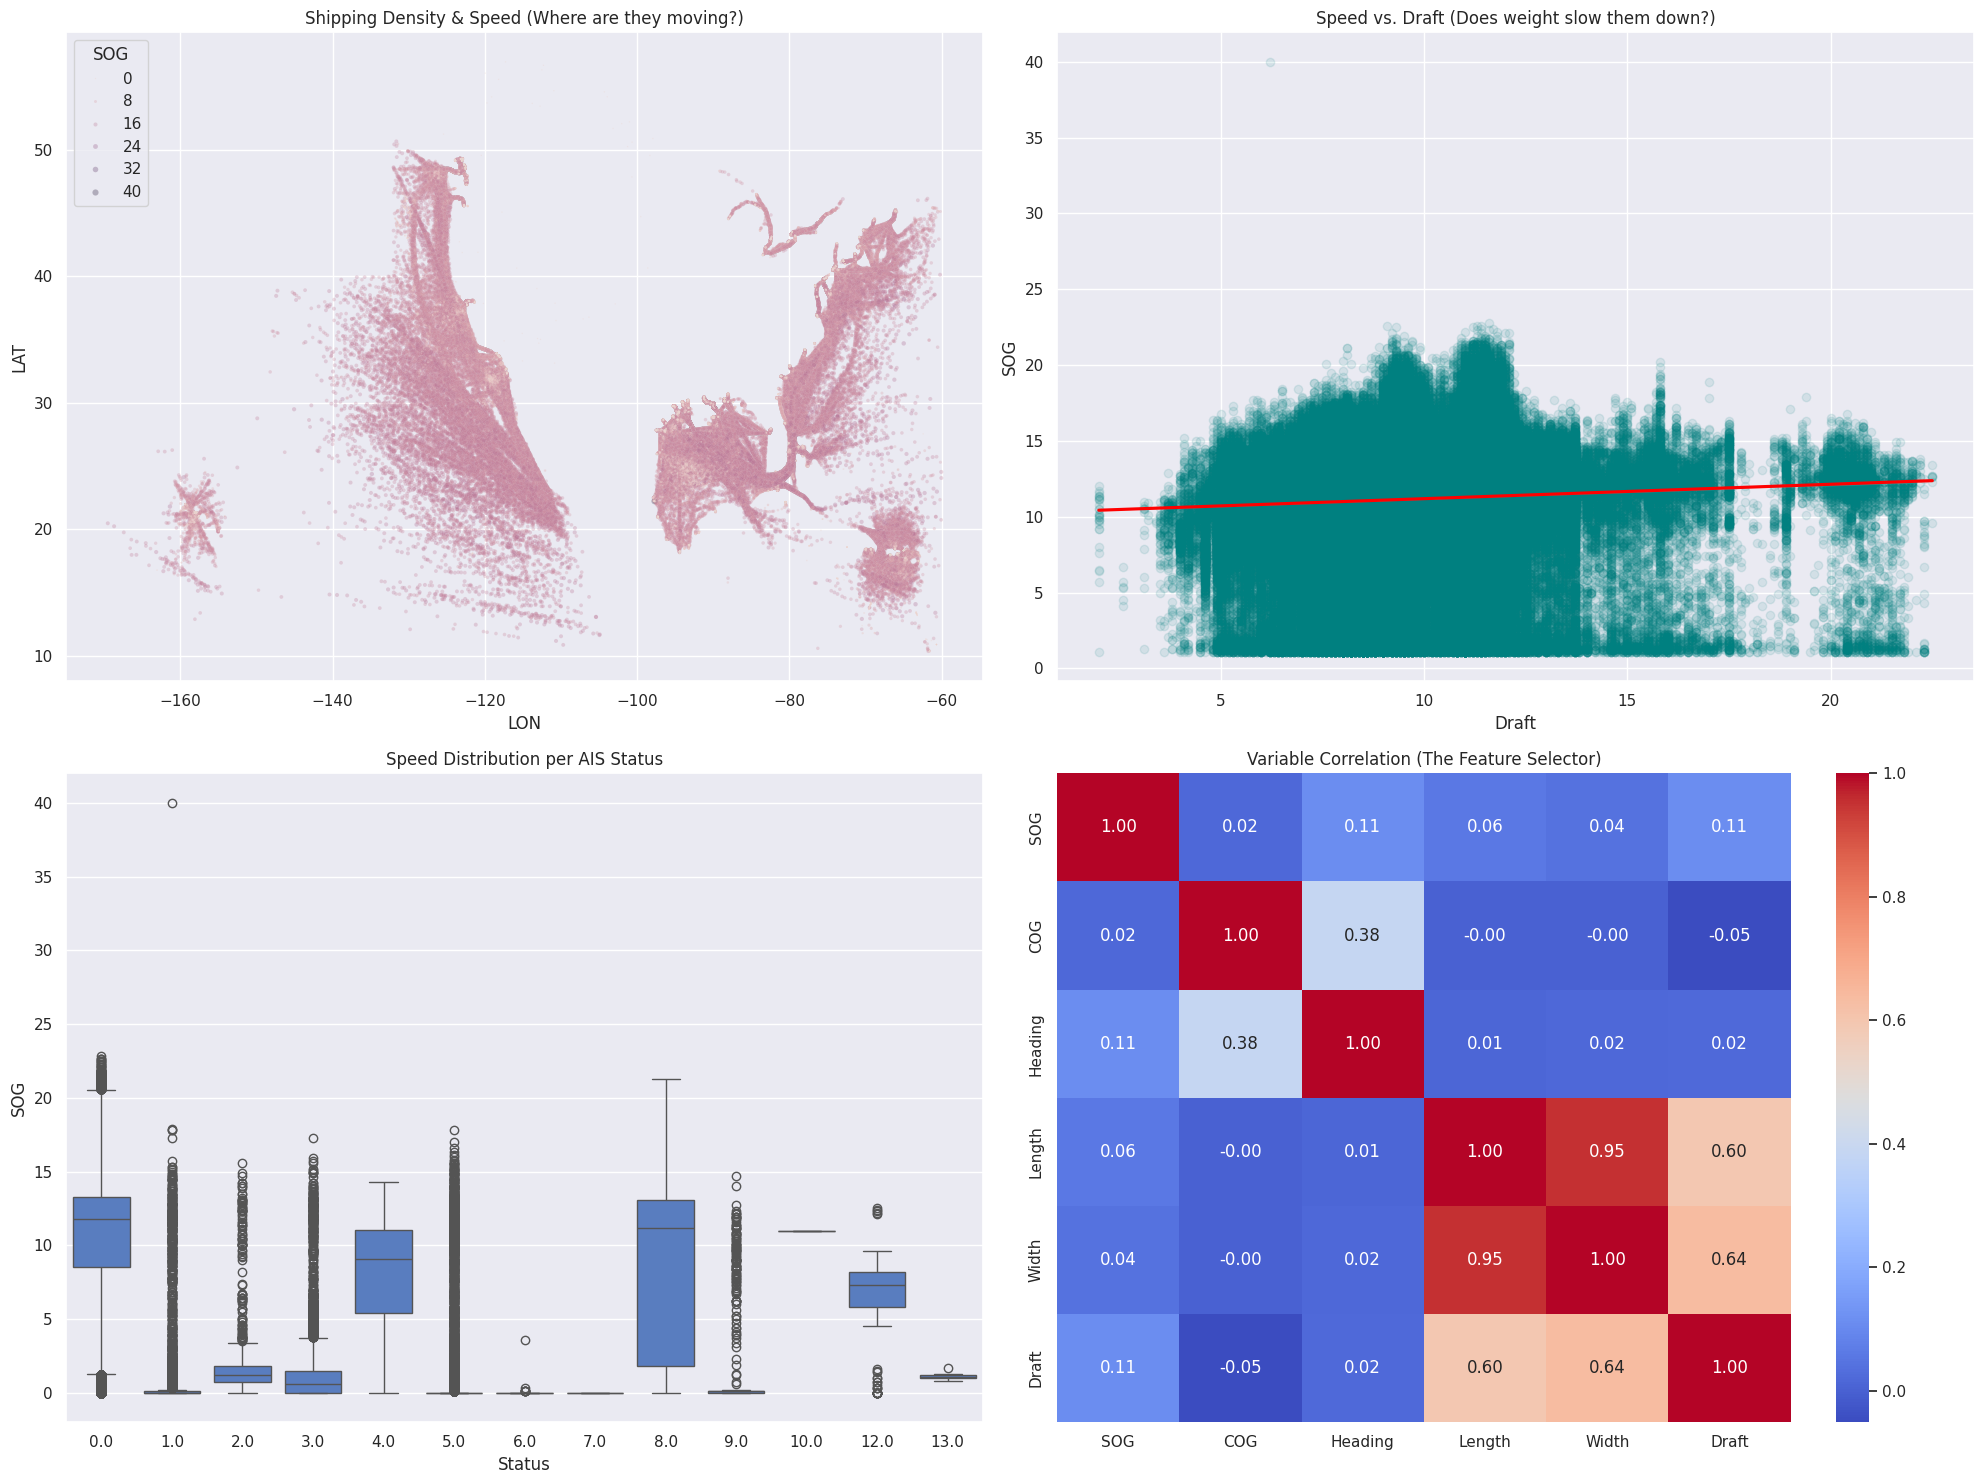

In [26]:

df_sample = df_final.sample(frac=0.2, random_state=42)

sns.set_theme(style="darkgrid", palette="muted")
fig, axes = plt.subplots(2, 2, figsize=(20, 15))

# PLOT 1
sns.scatterplot(data=df_sample, x='LON', y='LAT', hue='SOG',
                size='SOG', sizes=(1, 20), alpha=0.3, ax=axes[0, 0])
axes[0, 0].set_title('Shipping Density & Speed (Where are they moving?)')

#  PLOT 2
sns.regplot(data=df_sample[df_sample['SOG'] > 1], x='Draft', y='SOG',
            scatter_kws={'alpha':0.1, 'color':'teal'}, line_kws={'color':'red'}, ax=axes[0, 1])
axes[0, 1].set_title('Speed vs. Draft (Does weight slow them down?)')

#PLOT 3
sns.boxplot(data=df_sample, x='Status', y='SOG', ax=axes[1, 0])
axes[1, 0].set_title('Speed Distribution per AIS Status')

# PLOT 4
corr = df_final[['SOG', 'COG', 'Heading', 'Length', 'Width', 'Draft']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1, 1])
axes[1, 1].set_title('Variable Correlation (The Feature Selector)')

plt.tight_layout()
plt.show()

In [27]:
!pip install geoviews bokeh cartopy --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 574.7/574.7 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 70.6 MB/s eta 0:00:00


In [28]:
import geopandas as gpd
import holoviews as hv
import geoviews as gv
from holoviews import opts
from cartopy import crs

# Initialize Holoviews with Bokeh backend
hv.extension('bokeh')

df_map_sample = df_sample.sample(n=100000, random_state=42)

# Convert to GeoPandas
gdf = gpd.GeoDataFrame(
    df_map_sample,
    geometry=gpd.points_from_xy(df_map_sample.LON, df_map_sample.LAT),
    crs="EPSG:4326"
)

points = gv.Points(gdf, vdims=['SOG', 'MMSI', 'Length'], crs=crs.PlateCarree())

layout = gv.tile_sources.OSM * points.opts(
    opts.Points(
        color='SOG',
        cmap='viridis',
        size=3,
        alpha=0.5,
        tools=['hover'],
        width=800,
        height=600,
        colorbar=True,
        title="Interactive Fleet Map: Speed Distribution"
    )
)

layout

Output hidden; open in https://colab.research.google.com to view.

In [29]:
hubs = {'Bayou Bend': (29.6000, -94.0000), 'Pelican Hub': (30.5683, -90.6825)}
search_buffer = 0.60

target_mmsis = []
for name, (lat, lon) in hubs.items():
    mask = (df_final['LAT'].between(lat - search_buffer, lat + search_buffer)) & \
           (df_final['LON'].between(lon - search_buffer, lon + search_buffer))
    visited = df_final[mask]['MMSI'].unique()
    target_mmsis.extend(visited)

# Getting top 15 ships
df_hubs_all = df_final[df_final['MMSI'].isin(list(set(target_mmsis)))]
top_15_mmsis = df_hubs_all['MMSI'].value_counts().head(15).index.tolist()
df_plot = df_hubs_all[df_hubs_all['MMSI'].isin(top_15_mmsis)].sort_values(['MMSI', 'BaseDateTime'])

# Geodataframe
gdf_plot = gpd.GeoDataFrame(df_plot, geometry=gpd.points_from_xy(df_plot.LON, df_plot.LAT), crs="EPSG:4326")
gdf_plot['MMSI_STR'] = gdf_plot['MMSI'].astype(str)

# Graph
points = gv.Points(gdf_plot, vdims=['MMSI_STR', 'SOG', 'Draft', 'BaseDateTime'], crs=crs.PlateCarree(), label='Vessels')
hub_markers = gv.Points([(h[1], h[0]) for h in hubs.values()], crs=crs.PlateCarree(), label='CCS Hub Centers')

layout = gv.tile_sources.OSM * points.opts(
    opts.Points(color='MMSI_STR', cmap='Category20', size=4, alpha=0.6,
                tools=['hover', 'wheel_zoom', 'pan'], width=900, height=600,
                title="Gulf CCS Trajectories: Top 15 Vessel Candidates")
) * hub_markers.opts(
    opts.Points(size=12, color='red', marker='triangle')
)

layout

Output hidden; open in https://colab.research.google.com to view.

In [30]:
unique_fleet = list(set(target_mmsis))
total_count = len(unique_fleet)

print(f"Total unique ships that passed the CCS hubs: {total_count}")
print(f"Total rows of data for this fleet: {len(df_hubs_all):,}")


Total unique ships that passed the CCS hubs: 2477
Total rows of data for this fleet: 3,185,902


In [ ]:
hub_data = pd.DataFrame([
    {'name': 'Bayou Bend', 'lat': 29.6000, 'lon': -94.0000},
    {'name': 'Pelican Hub', 'lat': 30.5683, 'lon': -90.6825}
])

hub_points = gv.Points(hub_data, kdims=['lon', 'lat'], label='CCS Hubs').opts(
    size=12, color='red', marker='triangle', line_color='black', tools=['hover']
)

hub_labels = gv.Labels(hub_data, kdims=['lon', 'lat'], vdims='name').opts(
    text_font_size='12pt', text_color='red', text_font_style='bold', xoffset=0.2
)

# Selection
def select_ship_with_hubs(mmsi_selection):
    vessel_data = gdf_plot[gdf_plot['MMSI_STR'] == mmsi_selection]

    vessel_points = gv.Points(vessel_data, vdims=['MMSI_STR', 'SOG', 'Draft', 'BaseDateTime'],
                              crs=crs.PlateCarree())

    return gv.tile_sources.OSM * vessel_points.opts(
        opts.Points(color='SOG', cmap='plasma', size=6, alpha=0.8,
                    tools=['hover'], width=850, height=600, colorbar=True)
    ) * hub_points * hub_labels

ship_list = sorted(gdf_plot['MMSI_STR'].unique())
interactive_map = hv.HoloMap({m: select_ship_with_hubs(m) for m in ship_list}, kdims='Vessel MMSI')

interactive_map

In [32]:

# Major industrial starting points
source_data = pd.DataFrame([
    {'name': 'Houston Ship Channel', 'lat': 29.7500, 'lon': -95.1000},
    {'name': 'Port Arthur / Beaumont', 'lat': 29.8600, 'lon': -93.9300},
    {'name': 'Plaquemine (LA Corridor)', 'lat': 30.2900, 'lon': -91.2300}
])

hub_points = gv.Points(hub_data, kdims=['lon', 'lat'], label='Sequestration Hubs').opts(
    size=12, color='red', marker='triangle', line_color='black', tools=['hover']
)
hub_labels = gv.Labels(hub_data, kdims=['lon', 'lat'], vdims='name').opts(
    text_font_size='11pt', text_color='red', text_font_style='bold', xoffset=0.25
)

source_points = gv.Points(source_data, kdims=['lon', 'lat'], label='Industrial Sources').opts(
    size=10, color='dodgerblue', marker='circle', line_color='white', tools=['hover']
)
source_labels = gv.Labels(source_data, kdims=['lon', 'lat'], vdims='name').opts(
    text_font_size='10pt', text_color='dodgerblue', text_font_style='italic', xoffset=0.25
)


def select_ship_complete(mmsi_selection):
    vessel_data = gdf_plot[gdf_plot['MMSI_STR'] == mmsi_selection]

    vessel_points = gv.Points(vessel_data, vdims=['MMSI_STR', 'SOG', 'Draft', 'BaseDateTime'],
                              crs=crs.PlateCarree())

    return (gv.tile_sources.OSM * vessel_points.opts(opts.Points(color='SOG', cmap='plasma', size=6, alpha=0.8,
                                          tools=['hover'], width=900, height=650, colorbar=True,
                                          title=f"Logistics Path for MMSI: {mmsi_selection}")) * source_points * source_labels * hub_points * hub_labels)

ship_list = sorted(gdf_plot['MMSI_STR'].unique())
interactive_map = hv.HoloMap({m: select_ship_complete(m) for m in ship_list}, kdims='Vessel MMSI')

interactive_map

Output hidden; open in https://colab.research.google.com to view.

Filtering coordinates

In [33]:
lon = (-162.0, -150.0)
lat = (18.0, 23.0)

pacific_mmsis = df_final[
    (df_final['LON'].between(*lon)) &
    (df_final['LAT'].between(*lat))
]['MMSI'].unique()

#From these ships, checking which ones never visit the Gulf Hubs
mmsis_to_drop = [m for m in pacific_mmsis if m not in target_mmsis]

df_removedoutlierships = df_final[~df_final['MMSI'].isin(mmsis_to_drop)]

print(f"Removed {len(mmsis_to_drop)} ships that do not pass by the hubs.")
print(f"Remaining unique vessels: {df_removedoutlierships['MMSI'].nunique()}")

Removed 75 ships that do not pass by the hubs.
Remaining unique vessels: 3537


In [34]:
len(df_removedoutlierships)

4161906

In [35]:
df_removedoutlierships.describe()

,MMSI,LON,LAT,SOG,COG,Heading,Status,Length,Width,Draft,Cargo
count,4.161906e+06,4.161906e+06,4.161906e+06,4.161906e+06,4.158397e+06,4.161906e+06,4.161351e+06,4.161906e+06,4.161906e+06,4.161906e+06,4.161906e+06
mean,4.395532e+08,-9.406509e+01,3.085944e+01,4.399361e+00,1.884536e+02,1.740499e+02,1.722188e+00,2.064112e+02,3.443234e+01,9.301492e+00,8.138897e+01
std,1.443091e+08,1.498086e+01,6.269510e+00,5.929225e+00,1.008432e+02,1.003083e+02,2.119975e+00,5.274952e+01,9.534810e+00,2.441776e+00,2.982497e+00
min,2.050970e+08,-1.733146e+02,1.086790e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.400000e+01,4.000000e+00,7.000000e-01,8.000000e+01
25%,3.110012e+08,-9.530881e+01,2.783794e+01,0.000000e+00,1.096000e+02,9.200000e+01,0.000000e+00,1.820000e+02,2.800000e+01,7.900000e+00,8.000000e+01
50%,4.771297e+08,-9.427155e+01,2.936758e+01,1.000000e-01,1.855000e+02,1.670000e+02,1.000000e+00,1.830000e+02,3.200000e+01,8.800000e+00,8.000000e+01
75%,5.630706e+08,-8.453736e+01,3.232848e+01,1.110000e+01,2.756000e+02,2.630000e+02,5.000000e+00,2.440000e+02,4.300000e+01,1.080000e+01,8.000000e+01
max,7.100333e+08,-6.000097e+01,5.068187e+01,4.000000e+01,3.599000e+02,3.590000e+02,1.300000e+01,3.400000e+02,6.000000e+01,2.250000e+01,8.900000e+01


In [36]:
noise_lon = (-176.0, -112.0)
noise_lat = (21.0, 53.0)

outlier_mmsis = df_final[
    (df_final['LON'].between(*noise_lon)) &
    (df_final['LAT'].between(*noise_lat))
]['MMSI'].unique()

mmsis_to_permanently_drop = [m for m in outlier_mmsis if m not in target_mmsis]

df_removedoutlierships = df_removedoutlierships[~df_removedoutlierships['MMSI'].isin(mmsis_to_permanently_drop)]

print(f"Removed {len(mmsis_to_permanently_drop)} vessels that are local to Pacific/West Coast .")
print(f"Cleaned Row Count: {len(df_removedoutlierships):,}")
print(f"Unique Vessels remaining: {df_removedoutlierships['MMSI'].nunique()}")

Removed 447 vessels that are local to Pacific/West Coast .
Cleaned Row Count: 3,711,695
Unique Vessels remaining: 3164


In [37]:
df_removedoutlierships.describe()

,MMSI,LON,LAT,SOG,COG,Heading,Status,Length,Width,Draft,Cargo
count,3.711695e+06,3.711695e+06,3.711695e+06,3.711695e+06,3.708439e+06,3.711695e+06,3.711142e+06,3.711695e+06,3.711695e+06,3.711695e+06,3.711695e+06
mean,4.410207e+08,-9.104646e+01,2.998941e+01,4.408360e+00,1.888391e+02,1.711970e+02,1.744443e+00,2.044461e+02,3.401083e+01,9.163489e+00,8.138721e+01
std,1.454476e+08,1.243394e+01,5.550543e+00,5.974510e+00,1.003903e+02,9.993121e+01,2.128804e+00,5.163098e+01,9.199427e+00,2.240110e+00,2.961927e+00
min,2.050970e+08,-1.733146e+02,1.086790e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.400000e+01,4.000000e+00,7.000000e-01,8.000000e+01
25%,3.110011e+08,-9.502246e+01,2.781979e+01,0.000000e+00,1.107000e+02,9.000000e+01,0.000000e+00,1.800000e+02,2.800000e+01,7.800000e+00,8.000000e+01
50%,4.776072e+08,-9.382767e+01,2.930083e+01,1.000000e-01,1.866000e+02,1.630000e+02,1.000000e+00,1.830000e+02,3.200000e+01,8.700000e+00,8.000000e+01
75%,5.630894e+08,-8.244272e+01,3.001249e+01,1.110000e+01,2.751000e+02,2.580000e+02,5.000000e+00,2.430000e+02,4.200000e+01,1.070000e+01,8.000000e+01
max,7.100333e+08,-6.000097e+01,4.984544e+01,4.000000e+01,3.599000e+02,3.590000e+02,1.200000e+01,3.400000e+02,6.000000e+01,2.250000e+01,8.900000e+01


In [38]:

noise_lon = (-176.0, -112.0)
noise_lat = (21.0, 53.0)

outlier_mmsis = df_removedoutlierships[
    (df_removedoutlierships['LON'].between(*noise_lon)) &
    (df_removedoutlierships['LAT'].between(*noise_lat))
]['MMSI'].unique()

mmsis_to_permanently_drop = [m for m in outlier_mmsis]

df_westsidecompletelyremoved = df_removedoutlierships[~df_removedoutlierships['MMSI'].isin(mmsis_to_permanently_drop)]

print(f"Removed {len(mmsis_to_permanently_drop)} vessels that are local to Pacific/West Coast.")
print(f"Cleaned Row Count: {len(df_westsidecompletelyremoved):,}")
print(f"Unique Vessels remaining: {df_westsidecompletelyremoved['MMSI'].nunique()}")

Removed 826 vessels that are local to Pacific/West Coast.
Cleaned Row Count: 2,648,351
Unique Vessels remaining: 2338


In [39]:
# find every MMSI that has at least one ping in the Pacific noise zone
blacklist_mmsis = df_removedoutlierships[
    (df_removedoutlierships['LON'].between(-176.0, -112.0)) &
    (df_removedoutlierships['LAT'].between(21.0, 53.0))
]['MMSI'].unique()

df_westsidecompletelyremoved = df_removedoutlierships[
    ~df_removedoutlierships['MMSI'].isin(blacklist_mmsis)
].copy()

print(f"Total ships blacklisted: {len(blacklist_mmsis)}")
print(f"New Min Longitude: {df_westsidecompletelyremoved['LON'].min()}")

Total ships blacklisted: 826
New Min Longitude: -166.41744


In [40]:
(df_westsidecompletelyremoved['LON'] < -112.0).value_counts()

,count
LON,
False,2647523
True,828


In [41]:
df_westsidecompletelyremoved.describe()

,MMSI,LON,LAT,SOG,COG,Heading,Status,Length,Width,Draft,Cargo
count,2.648351e+06,2.648351e+06,2.648351e+06,2.648351e+06,2.645701e+06,2.648351e+06,2.647945e+06,2.648351e+06,2.648351e+06,2.648351e+06,2.648351e+06
mean,4.330324e+08,-8.784496e+01,2.967095e+01,4.324799e+00,1.880678e+02,1.686383e+02,1.749591e+00,2.059143e+02,3.431845e+01,9.116440e+00,8.147470e+01
std,1.470904e+08,9.081071e+00,5.392693e+00,5.933820e+00,1.002421e+02,9.983605e+01,2.132218e+00,5.746142e+01,1.028729e+01,2.379397e+00,3.036327e+00
min,2.052280e+08,-1.664174e+02,1.086790e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.400000e+01,1.000000e+01,2.000000e+00,8.000000e+01
25%,3.107950e+08,-9.467429e+01,2.779347e+01,0.000000e+00,1.084000e+02,8.800000e+01,0.000000e+00,1.690000e+02,2.600000e+01,7.600000e+00,8.000000e+01
50%,4.036520e+08,-9.308386e+01,2.923130e+01,1.000000e-01,1.872000e+02,1.620000e+02,1.000000e+00,1.830000e+02,3.200000e+01,8.800000e+00,8.000000e+01
75%,5.380117e+08,-8.018547e+01,2.995257e+01,1.090000e+01,2.726000e+02,2.530000e+02,5.000000e+00,2.500000e+02,4.400000e+01,1.060000e+01,8.100000e+01
max,7.100333e+08,-6.000097e+01,4.836985e+01,4.000000e+01,3.599000e+02,3.590000e+02,1.200000e+01,3.400000e+02,6.000000e+01,2.250000e+01,8.900000e+01


In [42]:
bad_ships = df_westsidecompletelyremoved[
    df_westsidecompletelyremoved['LON'] < -112
]['MMSI'].unique()

print(f" Found {len(bad_ships)} ships that violated the boundary.")
print(f" MMSIs: {bad_ships}")


df_completelyremovedoutliers = df_westsidecompletelyremoved[
    ~df_westsidecompletelyremoved['MMSI'].isin(bad_ships)
].copy()

if len(df_completelyremovedoutliers[df_completelyremovedoutliers['LON'] < -112]) == 0:
    print("VERIFIED: No traces of the blacklisted ships remain.")


 Found 52 ships that violated the boundary.
 MMSIs: [477736900 310774000 563171700 477928100 636011288 373568000 352001885
 636022583 636019927 636022162 565943000 538010118 353992000 538009582
 563200900 354453000 353812000 636020882 257405000 220555000 477722700
 370355000 636024374 352002349 538007028 538005809 636015187 563105300
 258645000 538006504 563119500 563622000 228420800 352002591 538003726
 255915868 636016613 563248100 477027700 311000478 352002691 538011752
 538006032 636023837 319515000 563096100 636017827 563257600 538011190
 538011238 352002825 538005015]
VERIFIED: No traces of the blacklisted ships remain.


In [43]:
df_completelyremovedoutliers.describe()

,MMSI,LON,LAT,SOG,COG,Heading,Status,Length,Width,Draft,Cargo
count,2.606728e+06,2.606728e+06,2.606728e+06,2.606728e+06,2.604081e+06,2.606728e+06,2.606358e+06,2.606728e+06,2.606728e+06,2.606728e+06,2.606728e+06
mean,4.325589e+08,-8.777183e+01,2.968726e+01,4.330101e+00,1.879751e+02,1.687652e+02,1.747286e+00,2.059625e+02,3.434974e+01,9.122699e+00,8.148917e+01
std,1.472188e+08,9.069140e+00,5.414688e+00,5.931315e+00,1.002296e+02,9.992569e+01,2.132199e+00,5.771707e+01,1.034235e+01,2.391071e+00,3.050633e+00
min,2.052280e+08,-1.065302e+02,1.086790e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.400000e+01,1.000000e+01,2.000000e+00,8.000000e+01
25%,3.107730e+08,-9.467222e+01,2.779103e+01,0.000000e+00,1.083000e+02,8.800000e+01,0.000000e+00,1.690000e+02,2.600000e+01,7.600000e+00,8.000000e+01
50%,4.036400e+08,-9.286523e+01,2.922786e+01,1.000000e-01,1.871000e+02,1.620000e+02,1.000000e+00,1.830000e+02,3.200000e+01,8.800000e+00,8.000000e+01
75%,5.380115e+08,-8.012317e+01,2.995939e+01,1.090000e+01,2.725000e+02,2.540000e+02,5.000000e+00,2.500000e+02,4.400000e+01,1.060000e+01,8.100000e+01
max,7.100333e+08,-6.000097e+01,4.836985e+01,4.000000e+01,3.599000e+02,3.590000e+02,1.200000e+01,3.400000e+02,6.000000e+01,2.250000e+01,8.900000e+01


In [44]:
df_completelyremovedoutliers.isnull().sum()

,0
MMSI,0
BaseDateTime,0
LON,0
LAT,0
SOG,0
COG,2647
Heading,0
IMO,5115
Status,370
Length,0


In [45]:
df_final2 = df_completelyremovedoutliers.copy()

## Resolve MMSI / IMO identity

In [47]:
clean_data = df_final2[(df_final2["IMO"] != 0) & (df_final2["IMO"].notna())]

# ship (IMO) changed its MMSI
imo_groups = clean_data.groupby("IMO")["MMSI"].nunique()
unstable_imos = imo_groups[imo_groups > 1]

# MMSI changed its IMO
mmsi_groups = clean_data.groupby("MMSI")["IMO"].nunique()
unstable_mmsis = mmsi_groups[mmsi_groups > 1]

print(f"IMOs that used multiple MMSIs:      {len(unstable_imos)}")
print(f"MMSIs that reported multiple IMOs:  {len(unstable_mmsis)}")
print("IMO is more stable" if len(unstable_imos) <= len(unstable_mmsis) else "MMSI is more stable")

IMOs that used multiple MMSIs:      45
MMSIs that reported multiple IMOs:  0
MMSI is more stable


In [48]:
# IMO is the more stable, so it's kept and MMSI is dropped
df_final2 = df_final2.drop(columns=["MMSI"])
print(df_final2.columns.tolist())

['BaseDateTime', 'LON', 'LAT', 'SOG', 'COG', 'Heading', 'IMO', 'Status', 'Length', 'Width', 'Draft', 'Cargo']


##  Filter AIS navigation status

In [49]:
df_final2["Status"].value_counts()

,count
Status,
0.0,1078519
1.0,761424
5.0,723262
3.0,30484
8.0,4492
9.0,3449
2.0,3313
12.0,628
4.0,516


- **Transit** — 0, 8: used to calculate fuel burn and travel time between capture and storage sites
- **Port/Stationary** — 1, 5: crucial for turnaround-time (TAT) and loading/unloading efficiency
- **Maneuvering** — 2, 3, 7: high-risk / low-speed zones, needed for safety variables in Monte Carlo sims
- **Too heavy** — 4: high-payload indicator or speed restriction
- **Outliers/noise** — 6, 9, 12, 13, 15


In [50]:
codes_remove = [6.0, 9.0, 12.0, 13.0, 15.0]

size_before = len(df_final2)
df_final2 = df_final2[~df_final2["Status"].isin(codes_remove)]
print(f"Remaining data: {len(df_final2):,} rows (dropped {size_before - len(df_final2):,}).")

Remaining data: 2,602,404 rows (dropped 4,324).


##  Filter by vessel / cargo type

In [51]:
df_final2["Cargo"].value_counts()

,count
Cargo,
80.0,1925997
89.0,334332
82.0,139785
84.0,83930
81.0,79755
83.0,22277
88.0,7672
85.0,5789
87.0,2764


- **80** — Tanker, generic: general vessel for bulk liquids or gases
- **81** — Tanker, Hazard A: major hazardous materials, highest danger level
- **82** — Tanker, Hazard B: hazardous materials dangerous to environment/safety
- **83** — Tanker, Hazard C: hazardous materials, minor danger
- **84** — Tanker, Hazard D: recognizable hazardous materials, low probability of major damage
- **85–88** — Reserved for future/regional use
- **89** — Tanker, no info: hazard level not defined/available

In [52]:
# any single ship (by IMO) report more than one cargo type over time
type_counts = df_final2.groupby("IMO")["Cargo"].nunique()
conflicted_ships = type_counts[type_counts > 1]
print(f"Found {len(conflicted_ships)} ships with conflicting vessel types.")

if len(conflicted_ships) > 0:
    print("\n Ships with multiple reported types : ")
    inconsistent_data = df_final[df_final["IMO"].isin(conflicted_ships.index)]
    print(inconsistent_data.groupby("IMO")["Cargo"].unique())

Found 300 ships with conflicting vessel types.

 Ships with multiple reported types : 
IMO
IMO1015088          [80.0, 82.0]
IMO1054620          [85.0, 80.0]
IMO8707771          [80.0, 83.0]
IMO9047764          [80.0, 82.0]
IMO9114232          [89.0, 82.0]
                     ...        
IMO9976886          [80.0, 82.0]
IMO9981257    [80.0, 82.0, 83.0]
IMO9981477          [84.0, 89.0]
IMO9986049    [84.0, 81.0, 80.0]
IMO9997969          [80.0, 81.0]
Name: Cargo, Length: 300, dtype: object


In [53]:
# ships that are toggle to/from type 89 ("no info") alongside a real code
ship_profiles = df_final2.groupby("IMO")["Cargo"].unique()
type_89_switchers = ship_profiles[ship_profiles.apply(lambda types: 89.0 in types and len(types) > 1)]

print(f"Found {len(type_89_switchers)} ships that toggled to/from type 89.")
print("\n Most common ones")
print(type_89_switchers.astype(str).value_counts().head())

Found 170 ships that toggled to/from type 89.

 Most common ones
Cargo
[80. 89.]    40
[89. 80.]    39
[82. 89.]    10
[89. 82.]     8
[89. 81.]     7
Name: count, dtype: int64


In [54]:
import numpy as np

df_final2['Cargo'] = df_final2['Cargo'].replace(89.0, np.nan)

# Replaces NaN with the most common valid Cargo code for that specific IMO
df_final2['Cargo'] = df_final2.groupby('IMO')['Cargo'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)
)

Relevant cargo types for this project are 80, 81, 84.

In [55]:
print(f"Original fleet size (rows): {len(df_final2):,}")
print(f"Original unique ships: {df_final2['IMO'].nunique()}")

target_types = [80, 81, 84]
relevant_imos = df_final2.loc[df_final2["Cargo"].isin(target_types), "IMO"].unique()
print(f"\nShips that used one of {target_types} at least once: {len(relevant_imos)}")

df_final2 = df_final2[df_final2["IMO"].isin(relevant_imos)].copy()
print(f"New fleet size (rows): {len(df_final2):,}")
print(f"Remaining vessel types: {sorted(df_final2['Cargo'].unique())}")

Original fleet size (rows): 2,602,404
Original unique ships: 2236

Ships that used one of [80, 81, 84] at least once: 1901
New fleet size (rows): 2,274,021
Remaining vessel types: [np.float64(80.0), np.float64(81.0), np.float64(82.0), np.float64(83.0), np.float64(84.0), np.float64(85.0), np.float64(86.0), np.float64(87.0), np.float64(88.0)]


## Ship size distributions

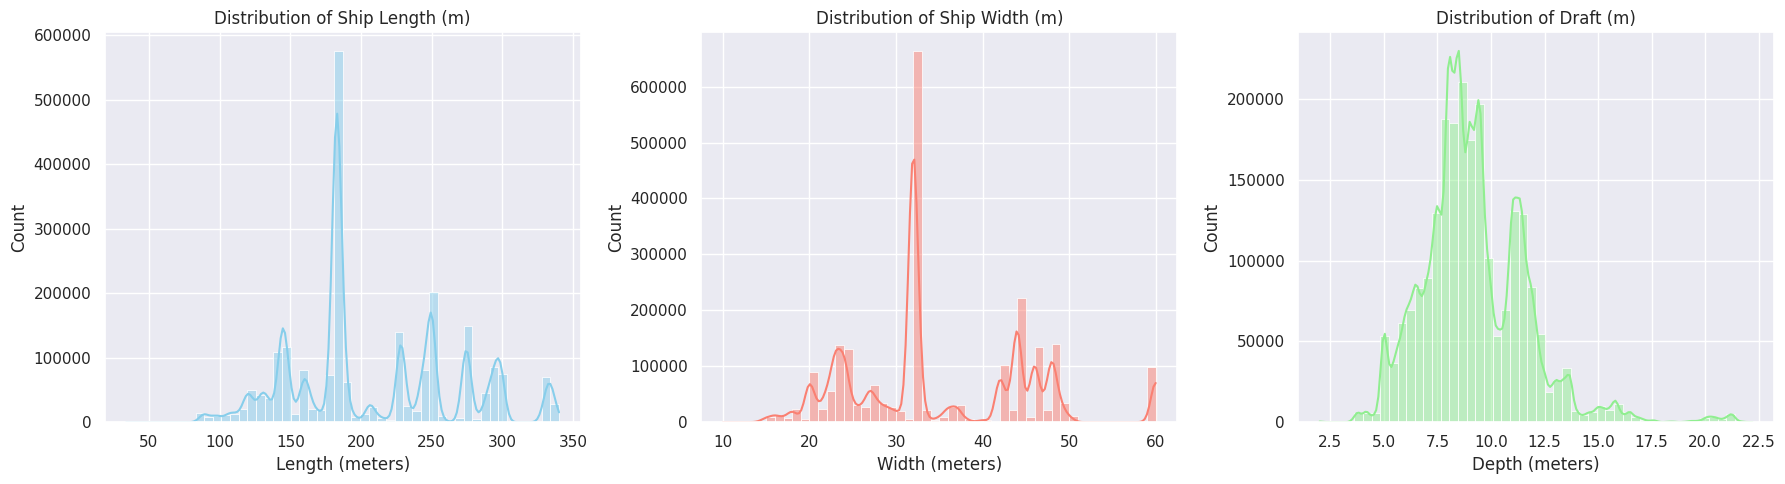

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df_final2["Length"], bins=50, ax=axes[0], color="skyblue", kde=True)
axes[0].set_title("Distribution of Ship Length (m)")
axes[0].set_xlabel("Length (meters)")

sns.histplot(df_final2["Width"], bins=50, ax=axes[1], color="salmon", kde=True)
axes[1].set_title("Distribution of Ship Width (m)")
axes[1].set_xlabel("Width (meters)")

sns.histplot(df_final2["Draft"], bins=50, ax=axes[2], color="lightgreen", kde=True)
axes[2].set_title("Distribution of Draft (m)")
axes[2].set_xlabel("Depth (meters)")

plt.tight_layout()
plt.show()


## Feature engineering - drift angle

Drift angle is the signed difference between heading (bow direction) and course-over-ground
(actual direction of travel), wrapped to (-180°, 180°].


In [57]:
diff = df_final2["Heading"] - df_final2["COG"]
df_final2["drift_angle"] = (diff + 180) % 360 - 180

In [58]:
print(df_final2.columns.tolist())
print()
print(df_final2.isnull().sum())

['BaseDateTime', 'LON', 'LAT', 'SOG', 'COG', 'Heading', 'IMO', 'Status', 'Length', 'Width', 'Draft', 'Cargo', 'drift_angle']

BaseDateTime       0
LON                0
LAT                0
SOG                0
COG             2422
Heading            0
IMO                0
Status           305
Length             0
Width              0
Draft              0
Cargo              0
drift_angle     2422
dtype: int64


## Outlier removal

Two cleanup passes: drop pings where the ship is essentially stationary (SOG < 1 knot - drift
angle is meaningless when a ship isn't moving), then drop extreme drift-angle outliers
(> 50°, likely AIS/sensor noise rather than real drift).

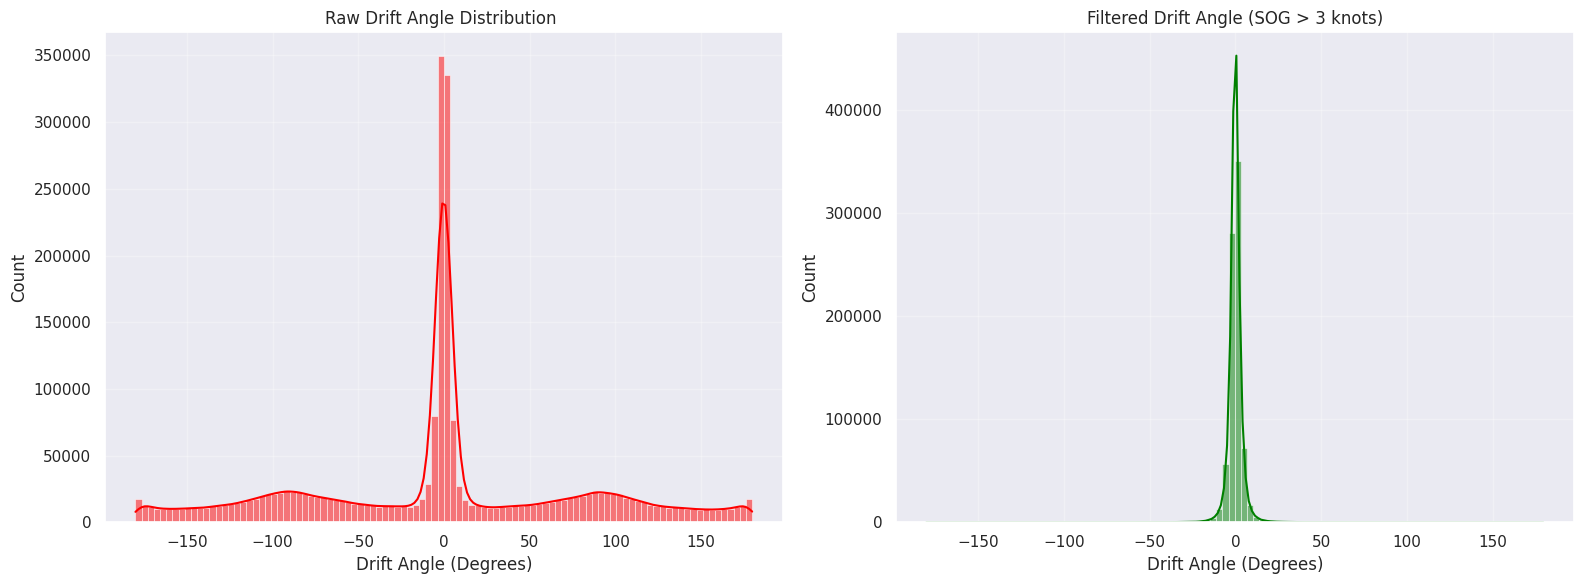

In [59]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df_final2["drift_angle"], bins=100, kde=True, ax=ax1, color="red")
ax1.set_title('Raw Drift Angle Distribution ')
ax1.set_xlabel("Drift Angle (Degrees)")
ax1.grid(True, alpha=0.3)

transit_df = df_final2[df_final2["SOG"] > 3.0]
sns.histplot(transit_df["drift_angle"], bins=100, kde=True, ax=ax2, color="green")
ax2.set_title('Filtered Drift Angle (SOG > 3 knots)')
ax2.set_xlabel("Drift Angle (Degrees)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

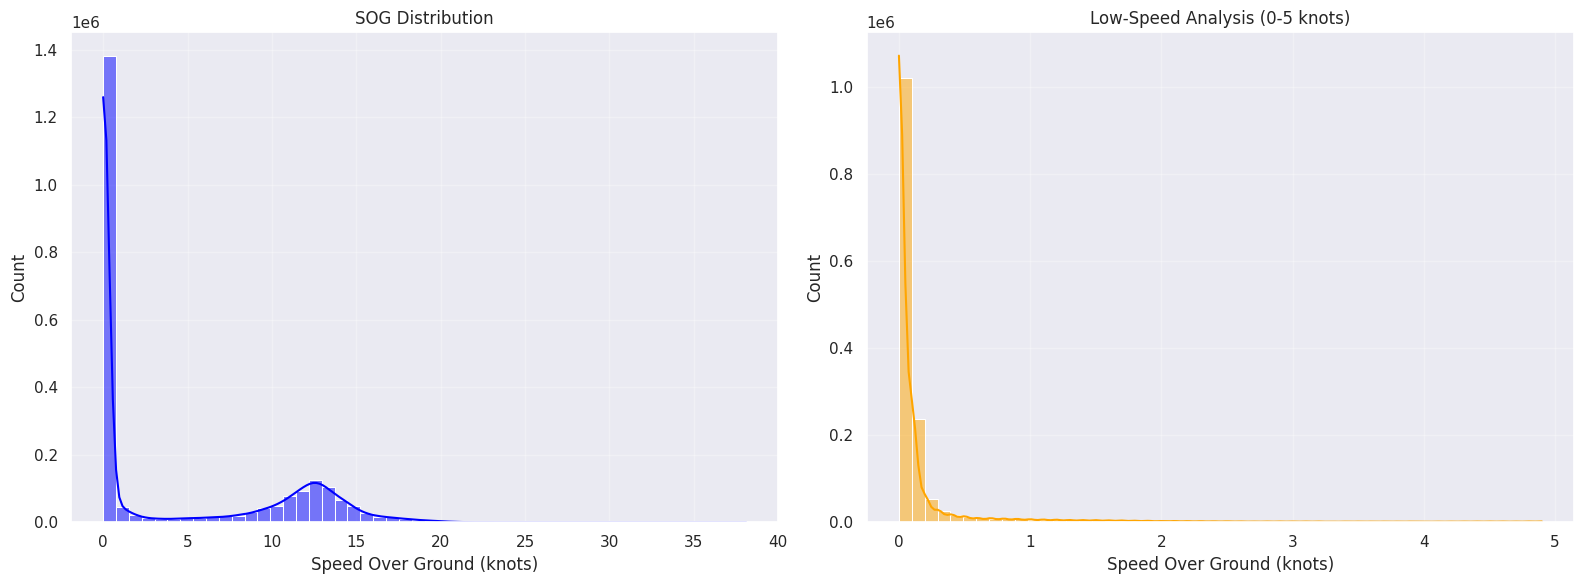

Total rows: 2,274,021
SOG < 1 knot : 1,396,731 (61.4%)


In [60]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df_final2["SOG"], bins=50, kde=True, ax=ax1, color="blue")
ax1.set_title('SOG Distribution')
ax1.set_xlabel("Speed Over Ground (knots)")
ax1.grid(True, alpha=0.3)

sns.histplot(df_final2[df_final2["SOG"] < 5]["SOG"], bins=50, kde=True, ax=ax2, color="orange")
ax2.set_title('Low-Speed Analysis (0-5 knots)')
ax2.set_xlabel("Speed Over Ground (knots)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

stopped = (df_final2["SOG"] < 1).sum()
print(f"Total rows: {len(df_final2):,}")
print(f"SOG < 1 knot : {stopped:,} ({stopped / len(df_final2) * 100:.1f}%)")

In [61]:
df_still_removed = df_final2[df_final2["SOG"] >= 1].copy()
print(f"Dropped {len(df_final2) - len(df_still_removed):,} rows where SOG < 1 knot.")
print(f"Remaining: {len(df_still_removed):,} rows (was {len(df_final2):,}).")

Dropped 1,396,731 rows where SOG < 1 knot.
Remaining: 877,290 rows (was 2,274,021).


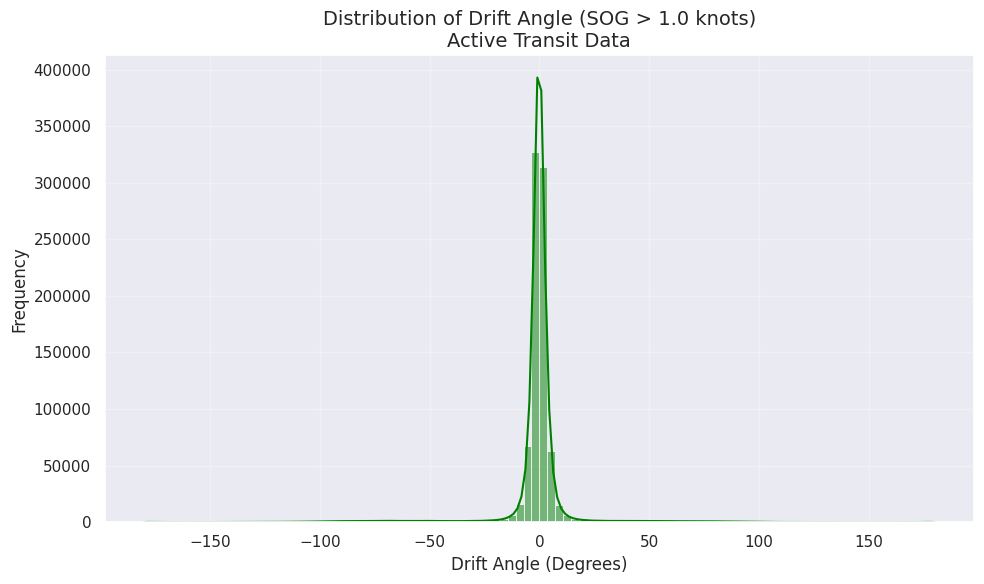

In [62]:
plt.figure(figsize=(10, 6))
sns.histplot(df_still_removed["drift_angle"], bins=100, kde=True, color="green")
plt.title("Distribution of Drift Angle (SOG > 1.0 knots)\nActive Transit Data", fontsize=14)
plt.xlabel("Drift Angle (Degrees)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [63]:
lower_limit, upper_limit = -50, 50
in_range = df_still_removed[df_still_removed["drift_angle"].between(lower_limit, upper_limit)]
pct_in_range = len(in_range) / len(df_still_removed) * 100
print(f"Rows between {lower_limit} and {upper_limit} deg: {len(in_range):,} ({pct_in_range:.1f}%)")

initial_len = len(df_still_removed)
df_still_removed = df_still_removed[df_still_removed["drift_angle"].abs() <= 50.0]
print(f"Dropped {initial_len - len(df_still_removed):,} rows with |drift angle| > 50 degrees.")

Rows between -50 and 50 deg: 843,432 (96.1%)
Dropped 33,858 rows with |drift angle| > 50 degrees.


In [64]:
print(f"Final fleet size: {len(df_still_removed):,} rows, {df_still_removed['IMO'].nunique()} unique ships\n")
df_still_removed.describe()

Final fleet size: 843,432 rows, 1897 unique ships



,LON,LAT,SOG,COG,Heading,Status,Length,Width,Draft,Cargo,drift_angle
count,843432.000000,843432.000000,843432.000000,843432.000000,843432.000000,843328.000000,843432.000000,843432.000000,843432.000000,843432.000000,843432.000000
mean,-84.888212,28.431830,11.566681,187.327041,185.446447,0.071738,212.089239,35.358079,9.533271,80.325343,-0.086637
std,8.975212,5.719067,3.540822,103.940626,103.748113,0.622081,58.479369,10.286429,2.500856,0.997204,6.546448
min,-106.016990,10.331240,1.000000,0.000000,0.000000,0.000000,34.000000,10.000000,2.000000,80.000000,-50.000000
25%,-93.632215,25.137170,10.200000,98.400000,97.000000,0.000000,180.000000,27.000000,8.000000,80.000000,-1.900000
50%,-85.277060,27.780380,12.200000,184.100000,183.000000,0.000000,186.000000,32.000000,9.200000,80.000000,-0.100000
75%,-79.378570,29.426652,13.600000,281.300000,279.000000,0.000000,250.000000,44.000000,11.100000,80.000000,1.600000
max,-60.000970,48.368040,37.600000,359.900000,359.000000,10.000000,340.000000,60.000000,22.200000,88.000000,50.000000


In [65]:
df_still_removed.isnull().sum()

,0
BaseDateTime,0
LON,0
LAT,0
SOG,0
COG,0
Heading,0
IMO,0
Status,104
Length,0
Width,0


## Removing outlier coordinates

In [67]:
# Define bounding box coordinates
lat_min, lat_max = 26, 32
lon_min, lon_max = -100, -85

# a mask to filter coordinates
mask = (df_still_removed['LAT'].between(lat_min, lat_max)) & \
       (df_still_removed['LON'].between(lon_min, lon_max))

unique_ships = df_still_removed[mask]['IMO'].nunique()
total_rows = mask.sum()

print(f"Total rows (pings) in the region: {total_rows}")
print(f"Total unique ships in the region: {unique_ships}")
print(f"total length of df {len(df)}")
print(f"percent of dataset that is in the region {total_rows/len(df)*100}")

Total rows (pings) in the region: 365318
Total unique ships in the region: 1720
total length of df 4286591
percent of dataset that is in the region 8.52234327930983


In [68]:
df_still_removed = df_still_removed[
    (df['LAT'].between(lat_min, lat_max)) &
    (df['LON'].between(lon_min, lon_max))
]
print(f"length of final df : {len(df_still_removed)} rows")

length of final df : 365318 rows


In [69]:
df_final_all_changes = df_still_removed.copy()

## Saving final file

In [71]:
df_final_all_changes.describe()

,LON,LAT,SOG,COG,Heading,Status,Length,Width,Draft,Cargo,drift_angle
count,365318.000000,365318.000000,365318.000000,365318.000000,365318.000000,365237.000000,365318.000000,365318.000000,365318.000000,365318.000000,365318.000000
mean,-92.987392,28.450503,10.892883,204.637402,201.762213,0.104110,212.444834,35.581477,9.521421,80.326754,-0.009521
std,2.564284,1.012536,3.499440,105.328522,105.787401,0.707487,56.844786,10.091635,2.400709,1.007026,6.642504
min,-97.521330,26.000010,1.000000,0.000000,0.000000,0.000000,34.000000,10.000000,2.000000,80.000000,-50.000000
25%,-94.660850,27.724123,9.300000,124.400000,123.000000,0.000000,182.000000,29.000000,8.000000,80.000000,-1.800000
50%,-93.747455,28.531840,11.700000,187.100000,184.000000,0.000000,186.000000,32.000000,9.100000,80.000000,-0.100000
75%,-90.917035,29.301997,13.100000,306.100000,305.000000,0.000000,250.000000,44.000000,11.100000,80.000000,1.600000
max,-85.000440,30.727620,37.600000,359.900000,359.000000,10.000000,340.000000,60.000000,22.200000,88.000000,50.000000


In [73]:
df_final_all_changes.head()

,BaseDateTime,LON,LAT,SOG,COG,Heading,IMO,Status,Length,Width,Draft,Cargo,drift_angle
11,2025-01-01 00:00:04,-90.29858,29.95597,14.3,40.7,41.0,IMO7816551,0.0,192.0,32.0,10.9,80.0,0.3
24,2025-01-01 00:00:03,-89.41682,29.35364,13.1,125.7,128.0,IMO9885908,0.0,229.0,35.0,13.9,80.0,2.3
26,2025-01-01 00:00:02,-95.20078,29.74000,4.6,52.9,54.0,IMO9724611,0.0,182.0,32.0,7.6,80.0,1.1
27,2025-01-01 00:00:07,-91.00400,30.16538,10.6,338.0,335.0,IMO9675078,0.0,147.0,23.0,8.4,81.0,-3.0
32,2025-01-01 00:00:04,-95.80819,27.19427,11.6,114.9,116.0,IMO9681857,0.0,183.0,32.0,8.2,80.0,1.1


In [74]:
#Saving final cleaned dataset
save_path = "/content/drive/MyDrive/LCO2 Transport Project Final"

file_name = 'cleaned_noaa_fleet_2025.csv'
df_final_all_changes.to_csv(os.path.join(save_path, file_name), index=False, compression='gzip')

print(f"Dataset successfully exported to Drive: {file_name}")

Dataset successfully exported to Drive: cleaned_noaa_fleet_2025.csv
